## COVID XGBoost: Predict Whether a Patient Has COVID

**Goal:** Same binary classification (Result: positive vs negative) using symptoms and demographics, with **XGBoost** tuned for **Fβ (β=2)** to favor recall without exploding false positives.

**Setup:** Same 60% train / 40% test, **random_state=321**, stratified split. Tune on a **60k stratified sample** with **RandomizedSearchCV** (30 iterations, 3-fold CV); then **refit the best model on the full training set** and evaluate on the held-out test set. A **threshold sweep** lets you pick the operating point (recall vs precision) for your use case. **scale_pos_weight** is set from the training data to handle ~10% positive class imbalance.

**Why Fβ=2?** β=2 weights recall more than precision, so we catch more positives while still caring about precision. Use the threshold sweep to pick a cutoff that meets your target recall (e.g. 0.70 or 0.80).

### 1. Data load and imports

In [30]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, classification_report,
    make_scorer, fbeta_score
)
from sklearn.base import clone
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

DATA_PATH = '../data/COVID_DATA_cleaned.csv'
df = pd.read_csv(DATA_PATH)
df.head(10)

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,1,0,1,0
6,0,0,0,0,0,0,0,1,1
7,0,0,0,0,0,0,1,1,1
8,0,0,0,0,0,1,0,1,0
9,0,0,0,0,0,0,1,0,0


### 2. Train/test split

In [31]:
X = df.drop(columns=['Result'])
y = df['Result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=321, stratify=y)
print('Train:', len(X_train), '| Test (validation):', len(X_test))
print('Train % positive:', f'{y_train.mean()*100:.2f}%')
print('Test % positive:', f'{y_test.mean()*100:.2f}%')

Train: 587095 | Test (validation): 391398
Train % positive: 10.53%
Test % positive: 10.53%


### 3. Tuning sample (60k, stratified)

In [32]:
TUNE_SAMPLE_SIZE = 60_000

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=TUNE_SAMPLE_SIZE,
    stratify=y_train,
    random_state=321
)

print(len(X_tune), y_tune.mean())

60000 0.1053


### 4. Hyperparameter tuning (Fβ, β=2) with RandomizedSearchCV

In [33]:
BETA = 2  # favor recall, but still cares about precision
fbeta_scorer = make_scorer(fbeta_score, beta=BETA)

# scale_pos_weight to handle ~90% negative / ~10% positive imbalance
scale_pos = (y_tune == 0).sum() / max((y_tune == 1).sum(), 1)

xgb = XGBClassifier(
    random_state=321,
    n_jobs=-1,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss'
)

param_distributions = {
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5, 10, 20],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0, 5.0],
    "reg_lambda": [0.1, 0.5, 1.0, 5.0, 10.0],
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=30,
    scoring=fbeta_scorer,
    cv=5,
    n_jobs=-1,
    random_state=321,
    verbose=1
)

search.fit(X_tune, y_tune)

print(f"Best params (F{BETA}):", search.best_params_)
print(f"Best CV score (F{BETA}):", f"{search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:04:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:04:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:04:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:04:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best params (F2): {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0.0, 'n_estimators': 600, 'min_child_weight': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV score (F2): 0.5533


### 5. Refit best model on full train and get test probabilities

In [34]:
best_xgb = clone(search.best_estimator_)
best_xgb.fit(X_train, y_train)

y_proba = best_xgb.predict_proba(X_test)[:, 1]
print('Refit on full train:', len(X_train), 'rows. Probabilities on test set ready.')

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:06:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Refit on full train: 587095 rows. Probabilities on test set ready.


### 6. Threshold sweep (pick recall vs precision tradeoff)

In [35]:
for t in [0.30, 0.35, 0.355, 0.36, 0.365, 0.37, 0.375, 0.38,0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    print(f"t={t:.3f}  recall={recall:.3f}  precision={precision:.3f}  fp={fp:,}  fn={fn:,}")

t=0.300  recall=0.794  precision=0.156  fp=176,591  fn=8,492
t=0.350  recall=0.794  precision=0.156  fp=176,591  fn=8,492
t=0.355  recall=0.576  precision=0.393  fp=36,742  fn=17,472
t=0.360  recall=0.576  precision=0.393  fp=36,742  fn=17,472
t=0.365  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.370  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.375  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.380  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.400  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.450  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.500  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.550  recall=0.542  precision=0.599  fp=14,917  fn=18,888
t=0.600  recall=0.542  precision=0.599  fp=14,917  fn=18,888


### 7. Evaluation at chosen threshold (default 0.5)

In [36]:
THRESHOLD = 0.37  # or set to t_opt from cell above to hit target recall
y_pred = (y_proba >= THRESHOLD).astype(int)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
auc = roc_auc_score(y_test, y_proba)

print('On validation (test) data, threshold =', THRESHOLD)
print('  Overall accuracy:', f'{acc:.4f}')
print('  Sensitivity (recall positive):', f'{sensitivity:.4f}')
print('  Specificity (recall negative):', f'{specificity:.4f}')
print('  AUC:', f'{auc:.4f}')
print('Confusion matrix (rows=actual, cols=pred) [Neg, Pos]:')
print(cm)
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

On validation (test) data, threshold = 0.37
  Overall accuracy: 0.9136
  Sensitivity (recall positive): 0.5417
  Specificity (recall negative): 0.9574
  AUC: 0.7695
Confusion matrix (rows=actual, cols=pred) [Neg, Pos]:
[[335268  14917]
 [ 18888  22325]]
              precision    recall  f1-score   support

    negative       0.95      0.96      0.95    350185
    positive       0.60      0.54      0.57     41213

    accuracy                           0.91    391398
   macro avg       0.77      0.75      0.76    391398
weighted avg       0.91      0.91      0.91    391398



### 8. Feature importance

In [37]:
imp = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Feature importance:')
print(imp)
print('\nMost important predictor:', imp.idxmax())

Feature importance:
Contact                0.549008
Headache               0.171276
Fever                  0.146818
Cough                  0.059128
Sore_Throat            0.041632
Shortness_Of_Breath    0.018677
Sex                    0.010451
Age_60_And_Above       0.003011
dtype: float32

Most important predictor: Contact


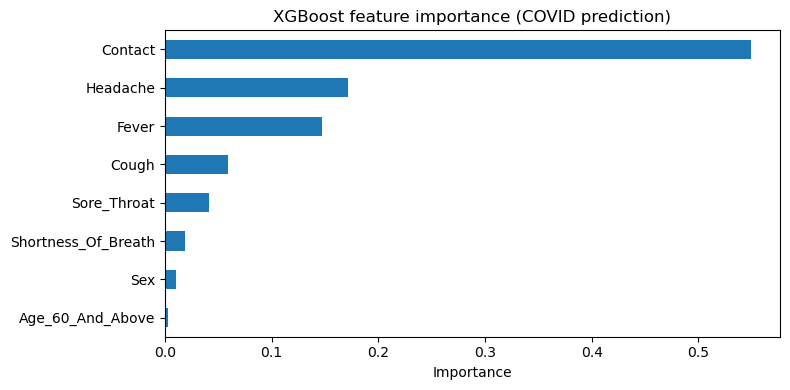

In [ ]:
imp.sort_values(ascending=True).plot(kind='barh', figsize=(8, 4), title='XGBoost feature importance (COVID prediction)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [39]:
import numpy as np

print(np.percentile(y_proba, [0, 10, 25, 50, 75, 90, 100]))

[0.2796829  0.29251653 0.29251653 0.35401136 0.35401136 0.3617616
 0.9971621 ]


Exception ignored in: <function ResourceTracker.__del__ at 0x10390dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105841bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10728dbc0>
Traceback (most recent call last